# 2. Initial Data Exploration

First look at the raw scraped data. Goal: identify quality issues that need handling before analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import sqlite3
from pathlib import Path

# SQLite connection. The repo ships with the populated DB.
DB_PATH = Path("..") / "data" / "processed" / "reviews.db"
engine = sqlite3.connect(DB_PATH)

# Load raw reviews (no features yet)
reviews = pd.read_sql("""
SELECT review_id, app_id, user_name, content, score, 
       review_date, developer_reply
FROM reviews
""", engine)

print(f"Shape: {reviews.shape}")
reviews.dtypes

Shape: (47188, 7)


review_id              str
app_id                 str
user_name              str
content                str
score              float64
review_date            str
developer_reply        str
dtype: object

## 2.1 Score Distribution

Are scores spread evenly across 1 to 5, or is there a pattern?

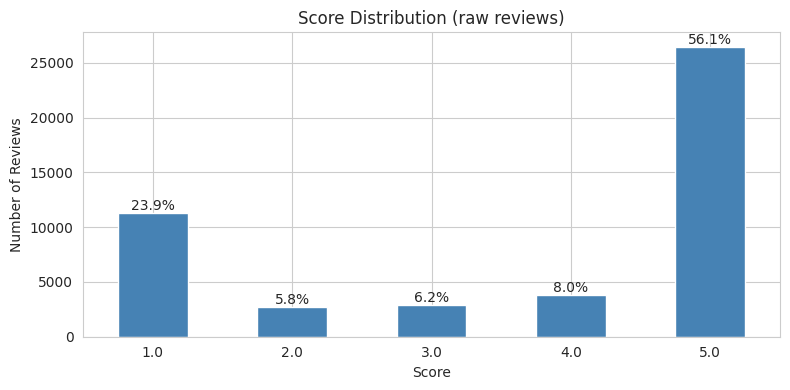

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
score_counts = reviews['score'].value_counts().sort_index()
score_counts.plot(kind='bar', ax=ax, color='steelblue')
total = score_counts.sum()
for i, v in enumerate(score_counts):
    ax.text(i, v, f"{v/total*100:.1f}%", ha='center', va='bottom')
ax.set_title('Score Distribution (raw reviews)')
ax.set_xlabel('Score')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2.2 Data Quality Issues

Three issues surface in the raw data:

1. **One review with no score**, a 2011 Bank Leumi review. Likely a pre-rating-system artifact.
2. **105 reviews with empty content**, users rated without writing text.
3. **Default usernames**, many reviews share the username `משתמש Google`, Google Play's default display name.

These motivate the cleaning and filtering steps in the next notebook.

In [3]:
# Missing values per column
missing = reviews.isna().sum()
missing_pct = (missing / len(reviews) * 100).round(1)
print("Missing values:")
print(pd.DataFrame({'n_missing': missing, 'pct': missing_pct})[missing > 0])

# The single no-score review
print("\nReview with no score:")
no_score = reviews[reviews['score'].isna()][['user_name', 'content', 'review_date']]
print(no_score.to_string(index=False))

# Top shared usernames
print("\nTop 5 most frequent usernames:")
print(reviews['user_name'].value_counts().head(5))

Missing values:
                 n_missing   pct
content                105   0.2
score                    1   0.0
developer_reply      24166  51.2

Review with no score:
   user_name                        content         review_date
משתמש Google אצלי עובד מעולה סוף סוף ללאומי 2011-02-20T19:17:40

Top 5 most frequent usernames:
user_name
משתמש Google    20613
יוסי כהן           14
חיים כהן           12
יעקב כהן           11
דוד כהן            11
Name: count, dtype: int64


## 2.3 Meaningful Absence vs Missing Data

Not all NULLs are equal. The `developer_reply` field is NULL for 51% of reviews, but this is not a data quality issue, it is meaningful absence: the developer simply did not respond. Treating it as missing would lose information. The right move is to encode it as a binary `has_developer_reply` feature in the cleaning step.

This also surfaces a business question: which apps reply to users most often?

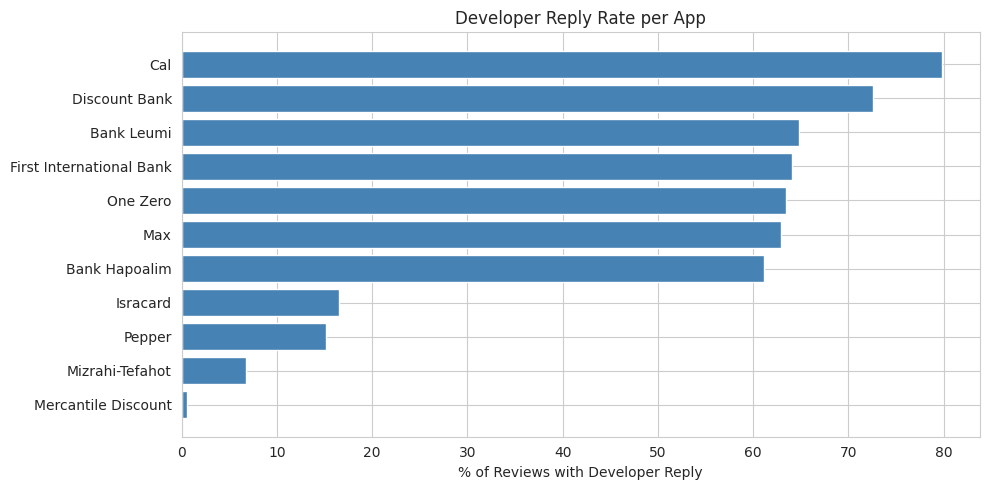

                    name  total  replied  reply_rate_pct
     Mercantile Discount    579        3        0.518135
         Mizrahi-Tefahot   3936      266        6.758130
                  Pepper   6915     1051       15.198843
                Isracard   3869      641       16.567589
           Bank Hapoalim  10476     6404       61.130202
                     Max   4917     3092       62.883872
                One Zero   1033      655       63.407551
First International Bank   1956     1253       64.059305
              Bank Leumi   5924     3840       64.821067
           Discount Bank   3280     2382       72.621951
                     Cal   4303     3435       79.828027


In [4]:
reply_rate = pd.read_sql("""
SELECT 
    a.name,
    COUNT(*) AS total,
    SUM(CASE WHEN r.developer_reply IS NOT NULL THEN 1 ELSE 0 END) AS replied,
    CAST(SUM(CASE WHEN r.developer_reply IS NOT NULL THEN 1 ELSE 0 END) * 100.0 
         / COUNT(*) AS DECIMAL(4,1)) AS reply_rate_pct
FROM reviews r
INNER JOIN apps a ON r.app_id = a.app_id
GROUP BY a.name
ORDER BY reply_rate_pct
""", engine)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(reply_rate['name'], reply_rate['reply_rate_pct'], color='steelblue')
ax.set_title('Developer Reply Rate per App')
ax.set_xlabel('% of Reviews with Developer Reply')
plt.tight_layout()
plt.show()

print(reply_rate.to_string(index=False))

## 2.4 Volume and Time Coverage

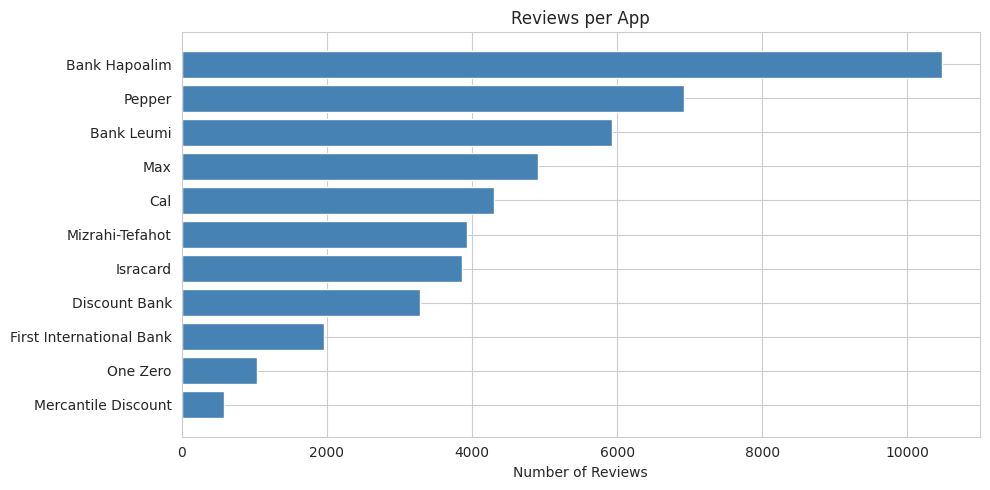

In [5]:
volume = pd.read_sql("""
SELECT a.name, COUNT(r.review_id) AS n
FROM apps a
LEFT JOIN reviews r ON a.app_id = r.app_id
GROUP BY a.name
ORDER BY n
""", engine)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(volume['name'], volume['n'], color='steelblue')
ax.set_title('Reviews per App')
ax.set_xlabel('Number of Reviews')
plt.tight_layout()
plt.show()

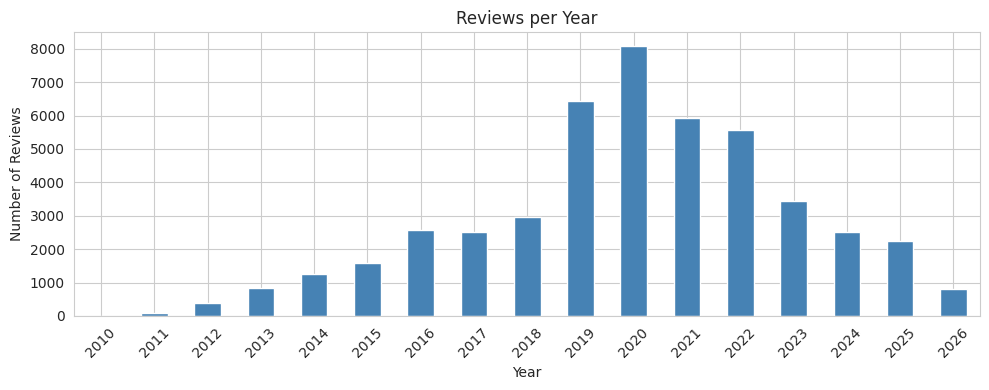

In [6]:
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
yearly = reviews.set_index('review_date').resample('YE').size()

fig, ax = plt.subplots(figsize=(10, 4))
yearly.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Reviews per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.set_xticklabels([str(d.year) for d in yearly.index], rotation=45)
plt.tight_layout()
plt.show()